In [1]:
import sys
import os
sys.path.append(os.path.abspath('..')) 

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Import the pipeline we already built!
from src.data_processing import clean_and_grid
from src.features import add_lag_features, add_rolling_features, add_target
from src.models import naive_forecast, train_ridge, train_random_forest, FEATURES, TARGET
from src.split import chronological_split
from src.evaluations import evaluate, comparison_table

import warnings
warnings.filterwarnings('ignore')

In [2]:
# 1. Run Data Pipeline
df = clean_and_grid("../data/raw-data/MEdata_07-03-26.csv")
df = add_lag_features(df)
df = add_rolling_features(df)
df = add_target(df)

# 2. Split Data
train_df, test_df, cutoff = chronological_split(df, train_frac=0.8)

# 3. Train Models
ridge_model = train_ridge(train_df)
rf_model = train_random_forest(train_df)

# 4. Evaluate
X_test = test_df[FEATURES].fillna(0)
y_true = test_df[TARGET]

results = [
    evaluate(y_true, naive_forecast(test_df), "Naive Baseline"),
    evaluate(y_true, ridge_model.predict(X_test), "Ridge Regression"),
    evaluate(y_true, rf_model.predict(X_test), "Random Forest"),
]

print(f"Test Set Horizon: {cutoff.date()} onwards")
display(comparison_table(results))

Test Set Horizon: 2023-12-09 onwards


,model,MAE,RMSE
0,Random Forest,45.727852,665.935898
1,Naive Baseline,48.872934,928.214304
2,Ridge Regression,58.134108,773.487175


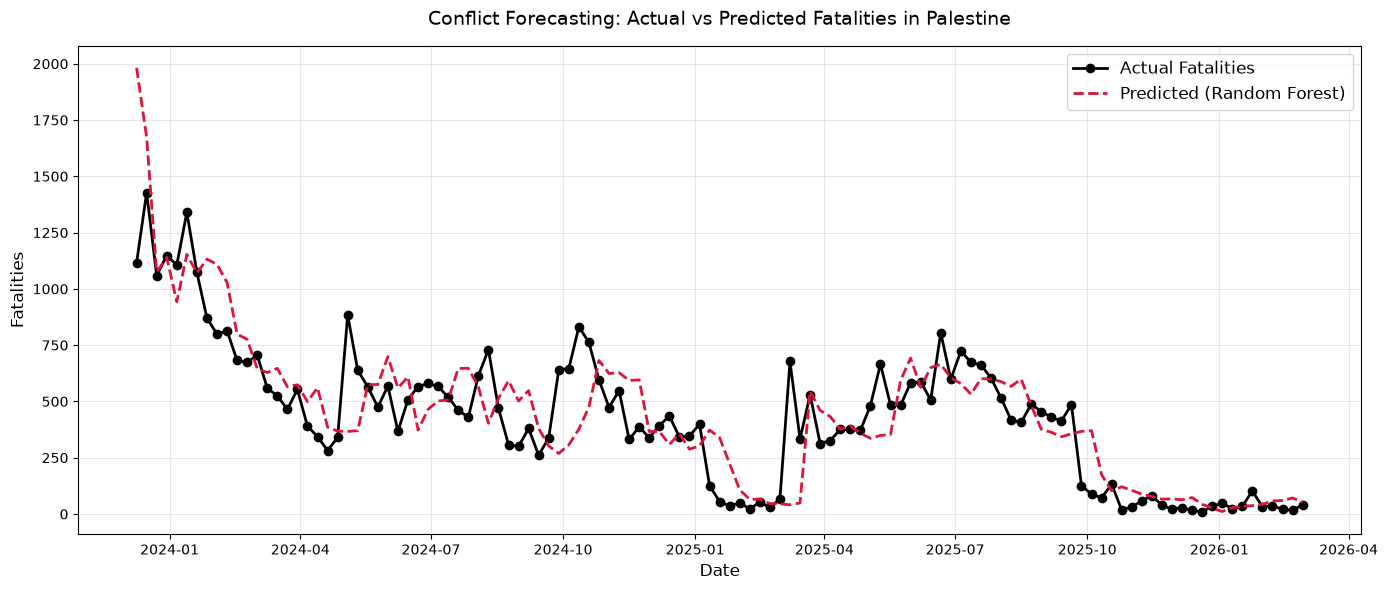

In [3]:
# Save predictions back to the test dataframe
test_df["RF_Prediction"] = rf_model.predict(X_test).round(0)

# Pick a highly volatile country to showcase the model's behavior
country_to_plot = "Palestine" 
plot_df = test_df[test_df["COUNTRY"] == country_to_plot].copy()

# Build the plot
plt.figure(figsize=(14, 6))
plt.plot(plot_df["WEEK"], plot_df[TARGET], label="Actual Fatalities", color='black', linewidth=2, marker='o')
plt.plot(plot_df["WEEK"], plot_df["RF_Prediction"], label="Predicted (Random Forest)", color='crimson', linewidth=2, linestyle='--')

plt.title(f"Conflict Forecasting: Actual vs Predicted Fatalities in {country_to_plot}", fontsize=14, pad=15)
plt.ylabel("Fatalities", fontsize=12)
plt.xlabel("Date", fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

# Predictive Modeling & Evaluation: Methodology and Results

This document outlines the machine learning pipeline used to forecast conflict fatalities, detailing our feature engineering, algorithmic choices, evaluation criteria, and the final conclusions drawn from our model's performance.

## 1. Feature Engineering & Temporal Transformations

Because time-series models require explicit historical context to make predictions, we transformed the raw Country-Week panel into a supervised learning dataset using the following temporal features:

*   **Autoregressive Lags ($y_{t-1}, y_{t-2}, y_{t-3}$):** We extracted the fatalities from the previous three weeks. This acts as the model's short-term memory, capturing the immediate persistence of conflict.
*   **Cross-Feature Lags:** We included the count of distinct conflict *events* from the previous week. Spikes in the number of events often precede spikes in fatalities.
*   **Rolling Statistics ($\mu_{t-1 \to t-4}, \sigma_{t-1 \to t-4}$):** We calculated the 4-week rolling mean and rolling standard deviation, strictly using historical windows to avoid data leakage. These features smooth out week-to-week volatility and help the model identify mid-term momentum and structural instability.
*   **Target Shifting:** We shifted the target variable backwards by one step ($\hat{y}_{t+1}$), training the model to map the state of the conflict at week $t$ to the fatalities that will occur in week $t+1$.

## 2. Algorithms Selected

We evaluated three distinct approaches to establish a hierarchy of predictive power:

### A. The Naive Baseline (Persistence Model)
**Formula:** $\hat{y}_{t+1} = y_t$
**Rationale:** In conflict forecasting, the strongest predictor of tomorrow's violence is today's violence. The naive assumption—that next week will have the exact same number of fatalities as this week—is the gold-standard benchmark. If a machine learning model cannot beat this, it is learning noise.

### B. Ridge Regression ($L_2$ Regularization)
**Formula:** $\min_{w} ||Xw - y||^2_2 + \alpha ||w||^2_2$
**Rationale:** Standard Ordinary Least Squares (OLS) regression fails when features are highly correlated (multicollinearity). Because our features (Lag 1, Lag 2, Rolling Mean) are highly collinear, we used Ridge Regression. The $\alpha$ penalty forces the model to shrink the coefficients of redundant features, stabilizing the predictions while keeping the relationship linear and highly interpretable.

### C. Random Forest Regressor
**Formula:** $\hat{y} = \frac{1}{N} \sum_{i=1}^{N} T_i(x)$
**Rationale:** Conflict escalation is rarely linear. Random Forest, an ensemble of 300 decision trees, captures non-linear thresholds (e.g., "If rolling variance is high AND Lag 1 > 100, predict an escalation"). It also requires no feature scaling and is highly robust to the extreme right-skew present in our fatality counts.

## 3. Evaluation Metrics

We evaluated the models using two metrics that respond differently to the dataset's extreme outliers:

*   **Mean Absolute Error (MAE):** 
    $$MAE = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|$$
    *Why we used it:* MAE scales linearly. It is easily interpretable ("On average, the model's prediction is off by X fatalities") and is not disproportionately hijacked by the top 1% of massive conflict spikes. This is our primary leaderboard metric.
*   **Root Mean Squared Error (RMSE):**
    $$RMSE = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2}$$
    *Why we used it:* RMSE squares the errors before averaging them, heavily penalizing large misses. In our context, a high RMSE indicates that while the model might be accurate day-to-day, it completely fails to foresee massive, sudden outbreaks of violence.

## 4. Final Results

The models were evaluated on a strict chronological holdout set (data from December 9, 2023, onwards) to simulate a real-world forecasting scenario.

| Model | MAE | RMSE |
| :--- | :--- | :--- |
| **Random Forest** | **45.73** | **665.94** |
| Naive Baseline | 48.87 | 928.21 |
| Ridge Regression | 58.13 | 773.49 |

## 5. Conclusions & Error Analysis

**1. Machine Learning Defeats the Baseline:** 
The Random Forest model successfully extracted valid predictive signal from the historical lags and rolling features, beating the Naive Baseline in both MAE and RMSE. Ridge Regression failed to beat the baseline MAE, suggesting that the relationship between historical lags and future fatalities is strictly non-linear.

**2. The Bimodal Accuracy Problem (The Spike Blindspot):**
Deep-dive error analysis revealed a massive discrepancy in the Random Forest's performance based on the severity of the conflict:
*   **Normal Weeks (Bottom 95%):** MAE of **~21 fatalities**.
*   **Extreme Spikes (Top 5%):** MAE of **~513 fatalities**.

**3. Final Verdict & Model Limitations:**
Our system is highly effective at tracking and forecasting ongoing, grinding conflicts. However, it systematically fails to predict sudden structural breaks (e.g., a sudden outbreak of a new war or a massive, unexpected attack). 

This is an inherent limitation of Autoregressive modeling and Random Forests:
1.  The model only looks at the past. If a geopolitical event triggers violence with no historical precedent in the preceding 4 weeks, the model is completely blind to it.
2.  Decision trees cannot extrapolate beyond their training data. If a new war produces 10,000 fatalities, but the training data maxed out at 2,000, the Random Forest is mathematically incapable of predicting 10,000. 

**Next Steps:** To improve spike prediction, future iterations must integrate external, leading indicators (e.g., economic data, social media sentiment, spatial neighbor-state violence) rather than relying exclusively on the country's own historical fatality counts.